**Decision trees**: it's an algorithm based on surface splitting either for regression or classification. At difference of Support Vector Machine, this doesn't divide the domain with a single surface, but with many horizontal and vertical splittings planes, attempting to separate the classes as better as possible in each iteration. This algorithm would perfectly separate the classes in a few iterations if they were arranged in rectangular clusters. For an extended friendly explanation see https://mlu-explain.github.io/decision-tree/

Remember that the entropy gain is given by

$$
\Delta H = H_{parent} - \sum_{i \in children} (N_i/N) H_i
$$

where $H$ is a measure of the impurity (it is by default the linear entropy in sklearn, but it is also common to use the Shannon entropy), $N_i$ the number of samples inside each child node, and N the total of samples. Here, the probabilities to be evaluated in each subset correspond to the proportion each feature has inside that subset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

iris = load_iris();

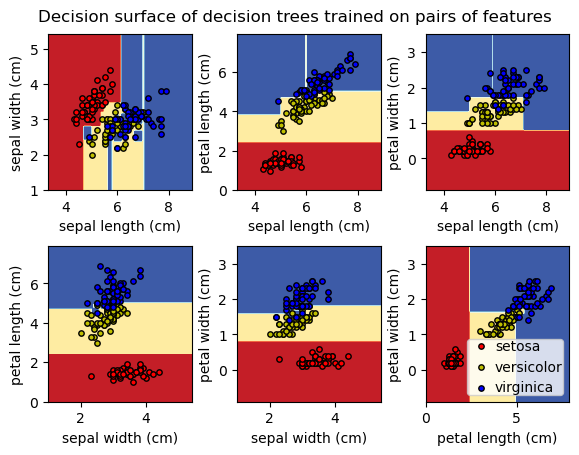

In [2]:
# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.asarray(y == i).nonzero()
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

Now, let's start with random forests. This basically consists in averaging many random trees to reduce the variance of the predictions. First, we start with the so-called bagging stage, where we randomly take many sub-samples of the data set (not necessarily mutually excluyent). Then, we perform a decision-tree fitting over each subset. Final decisions will be taken by averaging (if features are numbers) or by majority vote (if features are labels).

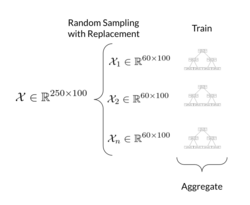

To reduce correlation among the outputs of the different trees, it is also usually selected a random subset of features at each candidate split during the training. This tutorial showed to be very informative: https://towardsdatascience.com/understanding-random-forest-using-python-scikit-learn/

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dataset: Breast Cancer Wisconsin (Diagnostic)
# Source: UCI Machine Learning Repository
# License: CC BY 4.0
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn import tree

In [2]:
# Load dataset
# Dataset: House Sales in King County (May 2014–May 2015)
# License CC0 1.0 Universal
url = 'https://raw.githubusercontent.com/mGalarnyk/Tutorial_Data/master/King_County/kingCountyHouseData.csv'

df = pd.read_csv(url)

columns = ['bedrooms',

            'bathrooms',

            'sqft_living',

            'sqft_lot',

             'floors',

             'waterfront',

             'view',

             'condition',

             'grade',

             'sqft_above',

             'sqft_basement',

             'yr_built',

             'yr_renovated',

             'lat',

             'long',

             'sqft_living15',

             'sqft_lot15',

             'price']

In [3]:
df = df[columns]
# Define features and target
X = df.drop(columns='price')
y = df['price']
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

params = {
    "n_estimators": 100,
    "max_features":1/3,
    #"max_depth": 4,
    #"min_samples_split": 5,
    #"warm_start":True,
    "oob_score":True,
    "random_state": 0,
}

In [4]:
#Fit the data
reg =RandomForestRegressor(**params)

reg.fit(X_train, y_train)

RandomForestRegressor(max_features=0.3333333333333333, oob_score=True,
                      random_state=0)

In [5]:
print(f"Baseline OOB score: {reg.oob_score_:.3f}")

Baseline OOB score: 0.861


We can use a function aimed at searching for the best parameters among a set of provided options.

In [6]:
param_grid = {
    'n_estimators': [100],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize model

rf = RandomForestRegressor(random_state=0, oob_score=True)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,             # 5-fold cross-validation
    scoring='r2',     # evaluation metric
    n_jobs=2
)

In [7]:
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R^2 score: {grid_search.best_score_:.3f}")

Best parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best R^2 score: 0.862
